In [11]:
#!/usr/bin/env python3
# analyze_L_cx.py
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# 1. 读取目录内的所有 json 文件
data_dir = Path("../result/Tokyo_max_gatelen=100_0812pm")   # <--- 改这里
records = []
for file in data_dir.rglob("*.json"):
    with open(file, "r") as f:
        rec = json.load(f)
        records.append({"L": rec["L"], "cx_ratio_diff": rec["cx_ratio_diff"]})

df = pd.DataFrame.from_records(records).dropna().sort_values("L")
print("样本量：", len(df))
print(df.head())


样本量： 40
      L  cx_ratio_diff
17  9.0      -0.306667
37  9.0      -0.066667
36  9.0      -0.065217
5   9.0      -0.133333
24  9.0      -0.060000


In [14]:
df.cx_ratio_diff.min(), df.cx_ratio_diff.max()

(np.float64(-0.3066666666666665), np.float64(8.024175824175824))

Pearson  r=0.759  p=0.000
Spearman ρ=0.816  p=0.000


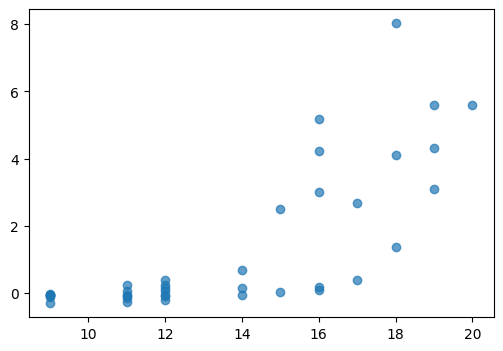

In [ ]:

# 2. 相关性
pearson_r, p_p = stats.pearsonr(df["L"], df["cx_ratio_diff"])
spearman_r, p_s = stats.spearmanr(df["L"], df["cx_ratio_diff"])
print(f"Pearson  r={pearson_r:.3f}  p={p_p:.3f}")
print(f"Spearman ρ={spearman_r:.3f}  p={p_s:.3f}")

# Pearson  r=0.759  p=0.000
# Spearman ρ=0.816  p=0.000
# 正相关，L越大，指标越差

# 3. 可视化
plt.figure(figsize=(6,4))
plt.scatter(df["L"], df["cx_ratio_diff"], alpha=0.7)


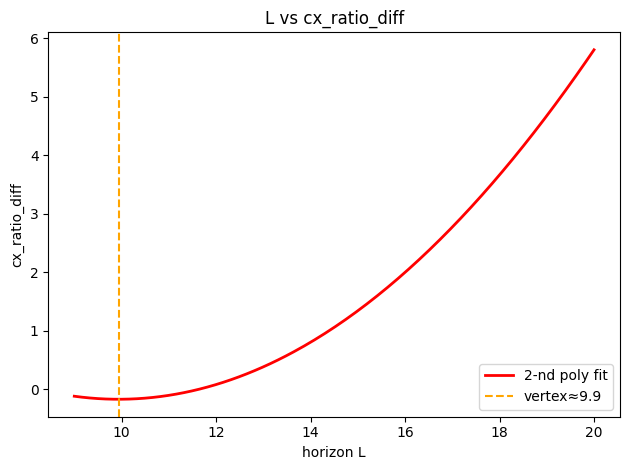

In [8]:

# 3.1 低阶多项式拟合（2次即可）
coeff = np.polyfit(df["L"], df["cx_ratio_diff"], deg=2)
poly  = np.poly1d(coeff)
L_smooth = np.linspace(df["L"].min(), df["L"].max(), 200)
plt.plot(L_smooth, poly(L_smooth), color="red", linewidth=2, label="2-nd poly fit")

# 3.2 拐点提示（二次函数极值点）
L_vertex = -coeff[1] / (2 * coeff[0])
plt.axvline(L_vertex, color="orange", linestyle="--", label=f"vertex≈{L_vertex:.1f}")
plt.legend()
plt.xlabel("horizon L")
plt.ylabel("cx_ratio_diff")
plt.title("L vs cx_ratio_diff")
plt.tight_layout()
plt.savefig("L_vs_cx_ratio_diff.png", dpi=300)
plt.show()

In [9]:
# 4. 分组统计（可选）
bins = pd.cut(df["L"], bins=range(int(df["L"].min()), int(df["L"].max())+2))
group = df.groupby(bins)["cx_ratio_diff"].agg(["mean", "count"])
print("\n按 L 区间的平均 cx_ratio_diff：")
print(group)


按 L 区间的平均 cx_ratio_diff：
              mean  count
L                        
(9, 10]        NaN      0
(10, 11] -0.044205      6
(11, 12]  0.065914      7
(12, 13]       NaN      0
(13, 14]  0.246909      3
(14, 15]  1.273308      2
(15, 16]  2.537112      5
(16, 17]  1.528656      2
(17, 18]  4.501099      3
(18, 19]  4.336009      3
(19, 20]  5.586000      1
(20, 21]       NaN      0


/var/folders/4d/fq7sssxx64s9kgphvvf_72lm0000gn/T/ipykernel_60837/1546858526.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(bins)["cx_ratio_diff"].agg(["mean", "count"])
